<a id="03"></a>

## 03 — Frequency Domain Analysis (FFT)
### Phần thứ hai của mục 0.2 — Phổ FFT, quan sát đỉnh dịch chuyển theo tải

**Mục đích**: vẽ FFT của cùng một loại lỗi qua các mức tải khác nhau, quan
sát các đỉnh phổ **dịch chuyển vị trí** trên trục Hz khi tải thay đổi (vì
tốc độ quay động cơ thay đổi theo tải) — đây chính là lý do cần Order-domain
Normalization ở notebook 04.

Notebook này cũng dùng để **chọn dải bandpass cho Square-Law Demodulation**
ở notebook 05 — quan sát vùng tần số có biên độ nổi bật nhất trên file có
lỗi rõ ràng.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [3]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = True

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [5]:
manifest = io_utils.apply_scope_filter(manifest)   

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## FFT của cùng 1 loại lỗi qua các mức tải (trục Hz)

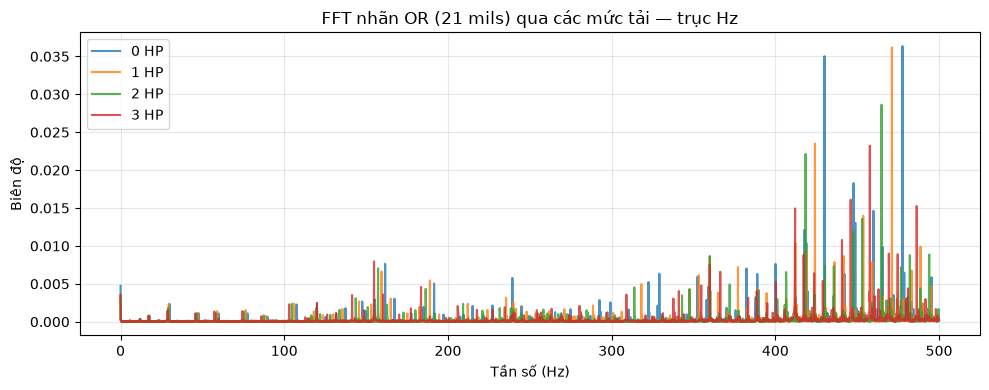

In [6]:
FAULT_LABEL = "OR"       # đổi nhãn muốn xem: "IR", "OR", "B"
DIAMETER_MILS = 21       # đường kính lỗi muốn xem (7/14/21 — trong phạm vi SKF)
FREQ_MAX_HZ = 500

fig, ax = plt.subplots(figsize=(10, 4))
signals_by_load = {}
for load_hp in sorted(manifest["load_hp"].dropna().unique()):
    load_hp = int(load_hp)
    try:
        fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp, diameter_mils=DIAMETER_MILS)
    except ValueError:
        continue
    x = io_utils.load_de_signal(Path(fp))
    signals_by_load[load_hp] = x
    freqs, mag = dsp.compute_fft(x, fs=12000)
    mask = freqs <= FREQ_MAX_HZ
    ax.plot(freqs[mask], mag[mask], label=f"{load_hp} HP", alpha=0.8)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ")
ax.set_title(f"FFT nhãn {FAULT_LABEL} ({DIAMETER_MILS} mils) qua các mức tải — trục Hz")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_fft_hz_across_loads.png", dpi=150)
plt.show()

## Đối chiếu với tần số lỗi lý thuyết

So vị trí đỉnh phổ quan sát được ở trên với BPFO/BPFI/BSF lý thuyết
(công thức SKF 6205, `common/config.py`) tại từng mức tải.

In [7]:
rows = []
for load_hp in sorted(signals_by_load.keys()):
    rpm = cfg.NOMINAL_RPM_BY_LOAD.get(load_hp)
    if rpm is None:
        continue
    freqs = cfg.bearing_fault_frequencies(rpm)
    rows.append({"load_hp": load_hp, "rpm_danh_dinh": rpm, **freqs})

theoretical_df = pd.DataFrame(rows).round(2)
theoretical_df.to_csv(TABLES_DIR / "03_theoretical_fault_freq_by_load.csv", index=False)
theoretical_df

,load_hp,rpm_danh_dinh,f_rot,BPFO,BPFI,BSF,FTF
0,0,1797,29.95,107.36,162.19,70.58,11.93
1,1,1772,29.53,105.87,159.93,69.60,11.76
2,2,1750,29.17,104.56,157.94,68.74,11.62
3,3,1730,28.83,103.36,156.14,67.95,11.48


# Tìm bandpass cho Square-Law Envelope Analysis

In [8]:
LOAD_HP = 0  # đổi mức tải muốn xem tại đây

labels_to_plot = ["Normal", "IR", "OR", "B"]
signals = {}
for label in labels_to_plot:
    fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : ..\..\data\raw\Normal\97_Normal_0.mat  (243938 mẫu)
IR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat  (121265 mẫu)
OR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat  (121991 mẫu)
B       : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat  (122571 mẫu)


In [9]:
import json
from common.pipeline import pick_file
from common.io_utils import load_de_signal
from common.dsp import compute_fft

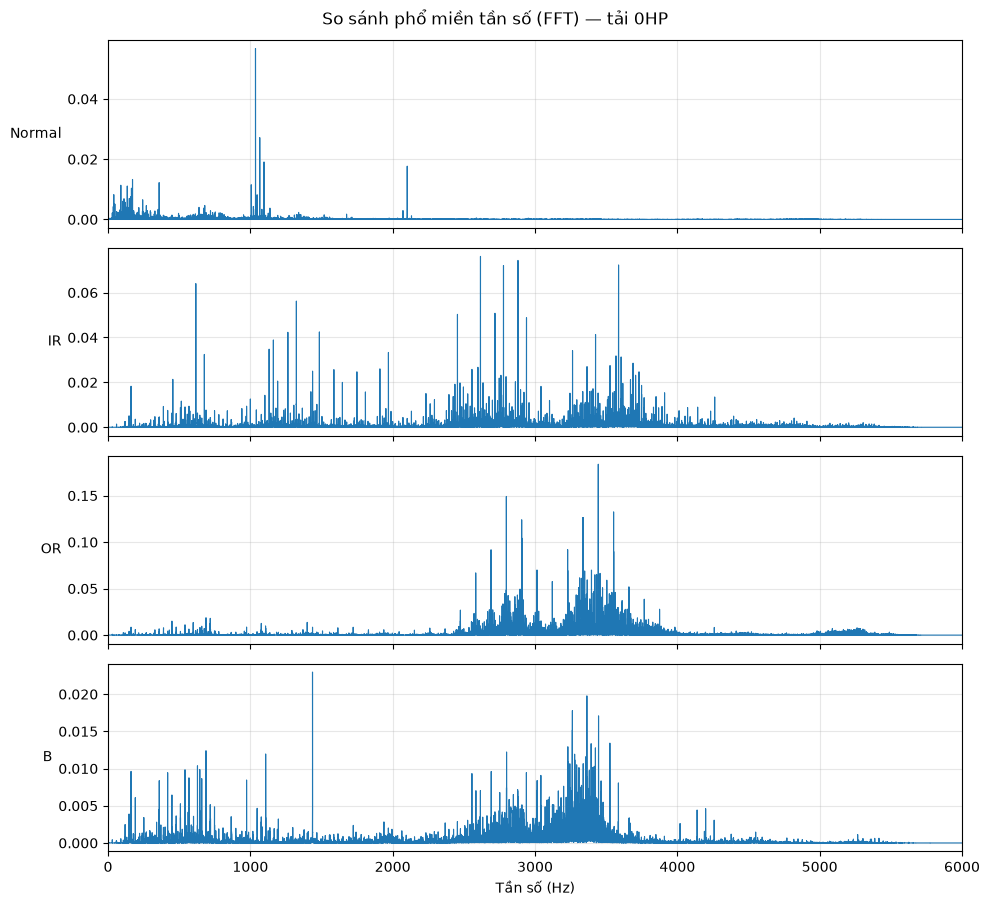

In [11]:
FS = 12000  # sampling rate của dữ liệu đang phân tích

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)

for ax, (label, x) in zip(axes, signals.items()):
    N = len(x)
    
    # 1. Tính toán biến đổi Fourier (nửa phổ dương cho tín hiệu thực)
    yf = np.fft.rfft(x)
    xf = np.fft.rfftfreq(N, 1 / FS)
    
    # 2. Chuẩn hóa biên độ (Amplitude)
    # Chia cho N và nhân 2 (ngoại trừ thành phần DC) để phản ánh đúng biên độ vật lý
    amplitude = np.abs(yf) / N
    amplitude[1:] = 2 * amplitude[1:]
    
    # 3. Vẽ đồ thị
    ax.plot(xf, amplitude, linewidth=0.8, color='#1f77b4')
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)
    
    # Giới hạn trục x từ 0 đến tần số Nyquist (6000 Hz)
    ax.set_xlim(0, FS / 2)

axes[-1].set_xlabel("Tần số (Hz)")
fig.suptitle(f"So sánh phổ miền tần số (FFT) — tải {LOAD_HP}HP")
fig.tight_layout()

# Nhớ thay đổi tên file lưu trữ để không đè lên hình miền thời gian
# fig.savefig(FIGURES_DIR / "03_frequency_domain_comparison.png", dpi=150)
plt.show()

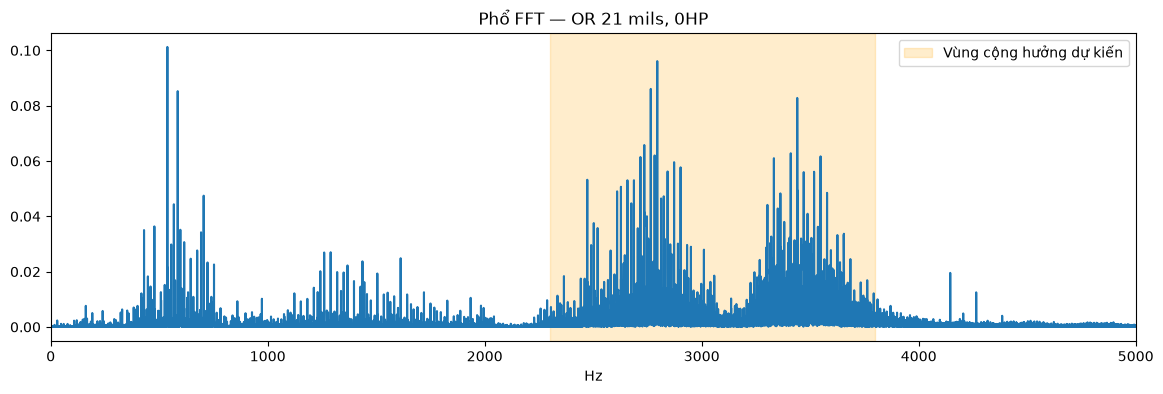

In [10]:
file_path = pick_file(manifest, label="OR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 5000)
plt.title("Phổ FFT — OR 21 mils, 0HP")

plt.axvspan(2300, 3800, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

## Quan sát

- Đỉnh phổ có dịch chuyển theo tải như bảng lý thuyết dự đoán không?
- Ghi lại dải tần số có biên độ nổi bật nhất (thường quanh vùng cộng hưởng
  cơ khí) — dùng làm điểm khởi đầu để chọn `band` cho Square-Law
  Demodulation ở notebook 05.

Hình đã lưu tại `outputs/figures/03_fft_hz_across_loads.png`.